# S&P 500 Options: Temporal Features

This notebook fits temporal volatility models walk-forward within CV folds and
extracts **daily-varying** features for the S&P 500 Options case study. Both
models share the same **fit-then-filter** paradigm:

1. **GJR-GARCH** (all security segments): Estimate parameters on training
   data, then filter each identity-stable series with fixed parameters to
   produce daily conditional volatility $h_t$.
2. **Bayesian Stochastic Volatility** (all security segments): Calibrate the vol-of-vol
   parameter $\sigma_\eta$ via MCMC on a liquid pool, then run a bootstrap
   particle filter independently for each segment.

Both models produce features for the **full date range** per fold (training
and validation periods), so downstream ML models can use temporal features during
both training and prediction. Validation and holdout rows are point-in-time.
Training rows are retrospective fold transforms because their parameters use
the complete training window.

**Learning Objectives**:
- Fit GJR-GARCH per security segment within each canonical training window
- Calibrate Bayesian SV hyperparameters via MCMC on a representative pool
- Run a bootstrap particle filter to produce daily SV volatility estimates
- Distinguish retrospective training transforms from point-in-time validation features

**Book Reference**: Chapter 9, Section 9.3 (Volatility Models)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) (features/financial.parquet)

In [1]:
"""S&P 500 Options: Temporal Features -- GJR-GARCH + Particle-Filtered SV."""

import hashlib
import logging
import subprocess
import warnings
from datetime import UTC, date, datetime, timedelta

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
import pytensor.tensor as pt
import yaml
from arch import arch_model
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import spearmanr

from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)

In [2]:
# Production defaults (Papermill overrides for testing)
SEED = 42
SV_POOL_SIZE = 10  # Symbols for MCMC sigma_eta calibration
SV_N_PARTICLES = 1000  # Particle filter resolution
SV_DRAWS = 2000  # MCMC draws per calibration symbol
SV_TUNE = 2000  # MCMC tuning steps
SV_CHAINS = 4  # MCMC chains
SV_TARGET_ACCEPT = 0.99
SV_RETRY_DRAWS = 4000
SV_RETRY_TUNE = 4000
LABEL_HORIZON_TRADING_DAYS = 21  # 25-35 calendar DTE; Newey-West uses 20 lags

In [3]:
CASE_DIR = get_case_study_dir("sp500_options")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"

STRATEGY_ID = "sp500_options"
set_global_seeds(SEED)

## 1. Load Data

In [4]:
prices = load_sp500_options_straddles()
print(f"Straddle instruments: {prices.shape}")

# Ch8 features for index reference
features = pl.read_parquet(FEATURES_DIR / "financial.parquet")
print(f"Features: {features.shape}")

symbols = prices["symbol"].unique().sort().to_list()
underlying = load_sp500_daily_bars(symbols=symbols)
print(f"Underlying: {underlying.shape[0]:,} rows, {underlying['symbol'].n_unique()} symbols")

_setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
_eval = load_evaluation_config(STRATEGY_ID)
holdout_start = str(_eval["holdout_start"])
holdout_end = str(_eval["holdout_end"])
label_buffer = str(_setup["labels"]["buffer"])
cv_folds = generate_cv_splits(
    features.select("timestamp"),
    case_study_id=STRATEGY_ID,
    label_buffer=label_buffer,
)
data_start = features["timestamp"].min()

print(f"\nCV folds: {len(cv_folds)}")
for fold in cv_folds:
    print(
        f"  Fold {fold['fold']}: train {fold['train_start']}..{fold['train_end']}, "
        f"validation {fold['val_start']}..{fold['val_end']}"
    )
print(f"  Holdout: {holdout_start}..{holdout_end}")

Straddle instruments: (361010, 44)
Features: (352212, 54)
Underlying: 631,926 rows, 627 symbols



CV folds: 2
  Fold 0: train 2018-01-05 00:00:00..2019-11-12 00:00:00, validation 2020-01-06 00:00:00..2020-12-31 00:00:00
  Fold 1: train 2017-02-02 00:00:00..2018-11-12 00:00:00, validation 2019-01-07 00:00:00..2020-01-03 00:00:00
  Holdout: 2021-01-01..2021-12-31


### Prepare Returns

GARCH and the particle filter both require adjusted returns scaled by 100 for
numerical stability. Security identity is part of the state key: a return,
fitted model, or latent volatility state never crosses a `sec_id` boundary.

In [5]:
reconciled_returns = reconcile_underlying_log_returns(underlying)
identity_boundaries = reconciled_returns.filter(pl.col("identity_boundary"))

returns_df = (
    reconciled_returns.with_columns((pl.col("clean_log_return") * 100).alias("log_ret_pct"))
    .filter(pl.col("log_ret_pct").is_not_null())
    .select(["timestamp", "symbol", "sec_id", "log_ret_pct"])
)

print(f"Returns: {returns_df.shape[0]:,} rows, {returns_df['symbol'].n_unique()} symbols")

print(
    f"Security identity boundaries: {identity_boundaries.height}; "
    "all boundary returns omitted before model fitting"
)

Returns: 631,272 rows, 627 symbols
Security identity boundaries: 15; all boundary returns omitted before model fitting


In [6]:
# Pre-load per-security return series (used by both GARCH and SV). Keeping
# `sec_id` in the key prevents any fitted or latent state from crossing a
# corporate identity boundary even when the displayed ticker is unchanged.
segment_returns: dict[tuple[str, int], pd.Series] = {}
for segment in returns_df.partition_by(["symbol", "sec_id"], maintain_order=True):
    symbol = segment["symbol"].item(0)
    sec_id = int(segment["sec_id"].item(0))
    segment_pd = segment.sort("timestamp").to_pandas().set_index("timestamp")
    if len(segment_pd) >= 100:
        segment_returns[(symbol, sec_id)] = segment_pd["log_ret_pct"]

print(
    f"Security segments with sufficient data: {len(segment_returns)} "
    f"across {len({key[0] for key in segment_returns})} symbols"
)

Security segments with sufficient data: 620 across 609 symbols


## 2. GJR-GARCH Temporal Features

GJR-GARCH captures the leverage effect: negative returns increase volatility
more than positive returns (Glosten, Jagannathan, and Runkle 1993).

The **fit-then-filter** paradigm:
1. **Fit** GJR-GARCH(1,1) parameters on the training window
2. **Filter** the full return series with an explicit causal recursion and
   fixed training-fit parameters, producing daily conditional volatility
   $h_t$ for every date
3. **Save** both training and validation period values

The validation segment is point-in-time because its fixed parameters use only
the preceding training window. Earlier training rows are retrospective
transforms under the parameters estimated from that complete window.

In [7]:
def causal_gjr_garch_filter(
    ret_series: pd.Series,
    params: pd.Series,
    scale: float,
    backcast: float,
    variance_bounds: tuple[float, float],
) -> pd.Series:
    """Apply a training-derived fixed GJR-GARCH recursion using only prior returns."""
    if ret_series.empty:
        return pd.Series(dtype=float, index=ret_series.index)

    mu = float(params.get("mu", params.get("Const", 0.0)))
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    gamma = float(params["gamma[1]"])
    beta = float(params["beta[1]"])
    lower_bound, upper_bound = variance_bounds

    scaled_residuals = ret_series.to_numpy(dtype=float) * scale - mu
    conditional_variance = np.empty(len(scaled_residuals), dtype=float)
    initial_variance = omega + (alpha + 0.5 * gamma + beta) * backcast
    conditional_variance[0] = np.clip(initial_variance, lower_bound, upper_bound)

    for t in range(1, len(scaled_residuals)):
        previous_residual = scaled_residuals[t - 1]
        innovation = previous_residual**2
        next_variance = (
            omega
            + alpha * innovation
            + gamma * innovation * (previous_residual < 0)
            + beta * conditional_variance[t - 1]
        )
        conditional_variance[t] = np.clip(next_variance, lower_bound, upper_bound)

    conditional_volatility = np.sqrt(conditional_variance) / scale
    return pd.Series(conditional_volatility, index=ret_series.index)

In [8]:
def fit_garch_with_retry(train_returns: pd.Series):
    """Fit GJR-GARCH once, then retry a nonconverged optimizer deterministically."""
    model = arch_model(
        train_returns,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        dist="Normal",
        rescale=True,
    )
    result = model.fit(disp="off", show_warning=False)
    retried = result.convergence_flag != 0
    if retried:
        result = model.fit(
            starting_values=result.params.to_numpy(),
            disp="off",
            show_warning=False,
            tol=1e-9,
            options={"maxiter": 2_000, "ftol": 1e-9},
        )
    return result, retried

In [9]:
def summarize_garch_fit(result, train_returns: pd.Series, retried: bool) -> dict:
    """Create one complete diagnostic record for an optimizer result."""
    persistence = (
        result.params.get("alpha[1]", 0)
        + result.params.get("beta[1]", 0)
        + result.params.get("gamma[1]", 0) / 2
    )
    return {
        "converged": result.convergence_flag == 0,
        "retried": retried,
        "convergence_flag": int(result.convergence_flag),
        "persistence": float(persistence),
        "log_likelihood": float(result.loglikelihood),
        "fit_start": train_returns.index.min(),
        "fit_end": train_returns.index.max(),
        "n_fit": len(train_returns),
        "error_type": None,
        "error_message": None,
    }

In [10]:
def training_garch_filter_state(result, train_returns: pd.Series) -> tuple[float, float, tuple]:
    """Derive scale, initialization, and static bounds from training data only."""
    fit_scale = float(result.model.scale)
    mu = float(result.params.get("mu", result.params.get("Const", 0.0)))
    train_residuals = train_returns.to_numpy(dtype=float) * fit_scale - mu
    backcast = float(result.model.volatility.backcast(train_residuals))
    train_bounds = result.model.volatility.variance_bounds(train_residuals)
    static_bounds = (
        float(train_bounds[:, 0].min()),
        float(train_bounds[:, 1].max()),
    )
    return fit_scale, backcast, static_bounds

In [11]:
def failed_garch_diagnostic(train_returns: pd.Series, retried: bool, exc: Exception) -> dict:
    """Create a denominator-preserving diagnostic for an eligible errored fit."""
    return {
        "converged": False,
        "retried": retried,
        "convergence_flag": None,
        "persistence": None,
        "log_likelihood": None,
        "fit_start": train_returns.index.min(),
        "fit_end": train_returns.index.max(),
        "n_fit": len(train_returns),
        "error_type": type(exc).__name__,
        "error_message": str(exc),
    }

In [12]:
def fit_gjr_garch_symbol(
    ret_series: pd.Series,
    train_start: date,
    train_end: date,
    filter_end: date,
) -> tuple[pd.Series | None, dict | None]:
    """Fit one eligible security segment and filter causally through ``filter_end``."""
    train_returns = ret_series[
        (ret_series.index >= pd.Timestamp(train_start))
        & (ret_series.index <= pd.Timestamp(train_end))
    ]
    filter_returns = ret_series[ret_series.index <= pd.Timestamp(filter_end)]
    if len(train_returns) < 252:
        return None, None

    retried = False
    try:
        result, retried = fit_garch_with_retry(train_returns)
        diagnostics = summarize_garch_fit(result, train_returns, retried)
        if not diagnostics["converged"]:
            return None, diagnostics
        fit_scale, backcast, static_bounds = training_garch_filter_state(result, train_returns)
        diagnostics.update(
            {
                "fit_scale": fit_scale,
                "backcast": backcast,
                "variance_lower_bound": static_bounds[0],
                "variance_upper_bound": static_bounds[1],
            }
        )
        filtered = causal_gjr_garch_filter(
            filter_returns, result.params, fit_scale, backcast, static_bounds
        )
        return filtered / 100 * np.sqrt(252), diagnostics
    except Exception as exc:
        return None, failed_garch_diagnostic(train_returns, retried, exc)

### Process All Symbols Across Folds

For each fold, GARCH features cover the full date range from training start
through validation end. The fixed-parameter filter produces values for every
date, so the retrospective training segment remains available to downstream
models alongside the point-in-time validation segment.

In [13]:
def run_garch_fold(fold: dict, segment_returns: dict) -> tuple[list, list, int]:
    """Fit and collect every eligible security segment for one CV fold."""
    fold_idx = fold["fold"]
    train_start, train_end, val_end = fold["train_start"], fold["train_end"], fold["val_end"]
    fold_results, fold_diagnostics = [], []
    skipped = 0
    for (symbol, sec_id), ret_series in segment_returns.items():
        cond_vol, diag = fit_gjr_garch_symbol(
            ret_series, train_start=train_start, train_end=train_end, filter_end=val_end
        )
        if diag:
            fold_diagnostics.append({"fold": fold_idx, "symbol": symbol, "sec_id": sec_id, **diag})
        if cond_vol is None:
            skipped += 1
            continue
        mask = (cond_vol.index >= pd.Timestamp(train_start)) & (
            cond_vol.index <= pd.Timestamp(val_end)
        )
        fold_vol = cond_vol[mask]
        if fold_vol.empty:
            skipped += 1
            continue
        fold_results.append(
            pl.DataFrame(
                {
                    "timestamp": fold_vol.index.values,
                    "symbol": symbol,
                    "sec_id": sec_id,
                    "garch_cond_vol": fold_vol.values,
                    "fold": fold_idx,
                }
            )
        )
    return fold_results, fold_diagnostics, skipped

In [14]:
garch_results = []
garch_diagnostics = []

for fold in cv_folds:
    print(
        f"\n--- GARCH Fold {fold['fold']}: train {fold['train_start']}..{fold['train_end']}, "
        f"validation ..{fold['val_end']} ---"
    )
    fold_results, fold_diagnostics, fold_skip = run_garch_fold(fold, segment_returns)
    garch_results.extend(fold_results)
    garch_diagnostics.extend(fold_diagnostics)

    print(f"  Fitted: {len(fold_results)} security segments, Skipped: {fold_skip}")


--- GARCH Fold 0: train 2018-01-05 00:00:00..2019-11-12 00:00:00, validation ..2020-12-31 00:00:00 ---


  Fitted: 495 security segments, Skipped: 125

--- GARCH Fold 1: train 2017-02-02 00:00:00..2018-11-12 00:00:00, validation ..2020-01-03 00:00:00 ---


  Fitted: 497 security segments, Skipped: 123


### GARCH Fit Quality

Convergence counts reveal whether the feature panel rests on broad coverage or
a small, selectively successful subset. The fitted panel retains every
successful optimization and reports convergence separately.

In [15]:
if not garch_diagnostics:
    raise RuntimeError("No eligible GARCH fits produced diagnostics")

garch_fit_summary = (
    pl.DataFrame(garch_diagnostics)
    .group_by("fold")
    .agg(
        pl.len().alias("fitted"),
        pl.col("converged").sum().alias("converged"),
        pl.col("persistence").mean().alias("mean_persistence"),
    )
    .sort("fold")
)
convergence_rate = garch_fit_summary["converged"].sum() / garch_fit_summary["fitted"].sum()
failed = garch_fit_summary["fitted"] - garch_fit_summary["converged"]

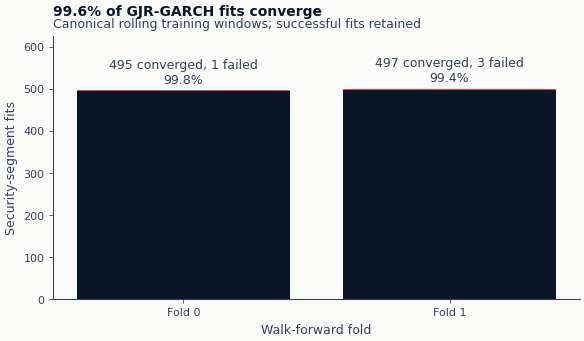

In [16]:
fig, ax = plt.subplots()
fold_labels = [f"Fold {fold}" for fold in garch_fit_summary["fold"]]
converged_bars = ax.bar(fold_labels, garch_fit_summary["converged"], color=COLORS["blue"])
ax.bar(
    fold_labels,
    failed,
    bottom=garch_fit_summary["converged"],
    color=COLORS["negative"],
)
for bar, converged, fitted in zip(
    converged_bars,
    garch_fit_summary["converged"],
    garch_fit_summary["fitted"],
    strict=True,
):
    n_failed = fitted - converged
    ax.annotate(
        f"{converged} converged, {n_failed} failed\n{converged / fitted:.1%}",
        (bar.get_x() + bar.get_width() / 2, fitted),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
    )
ax.set(xlabel="Walk-forward fold", ylabel="Security-segment fits")
ax.set_ylim(0, garch_fit_summary["fitted"].max() * 1.25)
fig.subplots_adjust(top=0.82)
add_message_title(
    ax,
    f"{convergence_rate:.1%} of GJR-GARCH fits converge",
    subtitle="Canonical rolling training windows; successful fits retained",
)
fig.show()

### Holdout Pass

Fit GARCH on all pre-holdout data and generate features from data start
through holdout end. The 2017-2020 rows are retrospective transforms under
the final pre-holdout fit; the sealed 2021 holdout rows are point-in-time.

In [17]:
holdout_train_end = (date.fromisoformat(holdout_start) - timedelta(days=1)).isoformat()
print(f"\n--- GARCH Holdout: train up to {holdout_train_end}, predict ..{holdout_end} ---")
holdout_count = 0
for (symbol, sec_id), ret_series in segment_returns.items():
    cond_vol, diag = fit_gjr_garch_symbol(
        ret_series,
        train_start=data_start,
        train_end=date.fromisoformat(holdout_train_end),
        filter_end=date.fromisoformat(holdout_end),
    )
    if diag:
        garch_diagnostics.append({"fold": -1, "symbol": symbol, "sec_id": sec_id, **diag})
    if cond_vol is None:
        continue

    date_from = pd.Timestamp(data_start)
    date_to = pd.Timestamp(holdout_end)
    mask = (cond_vol.index >= date_from) & (cond_vol.index <= date_to)
    fold_vol = cond_vol[mask]

    if len(fold_vol) == 0:
        continue

    holdout_count += 1
    garch_results.append(
        pl.DataFrame(
            {
                "timestamp": fold_vol.index.values,
                "symbol": symbol,
                "sec_id": sec_id,
                "garch_cond_vol": fold_vol.values,
                "fold": -1,
            }
        )
    )

print(f"  Holdout fitted: {holdout_count} security segments")


--- GARCH Holdout: train up to 2020-12-31, predict ..2021-12-31 ---


  Holdout fitted: 561 security segments


In [18]:
def validate_segment_feature_panel(frame: pl.DataFrame, value_col: str) -> None:
    """Validate identity provenance, output uniqueness, and numeric coverage."""
    if frame.is_empty():
        raise RuntimeError(f"No {value_col} features were generated")

    key_cols = ["timestamp", "symbol", "fold"]
    duplicate_keys = int(frame.select(key_cols).is_duplicated().sum())
    if duplicate_keys:
        raise RuntimeError(f"{value_col} contains {duplicate_keys} duplicate output keys")

    identity_cols = ["timestamp", "symbol", "sec_id"]
    valid_identities = returns_df.select(identity_cols).unique()
    unknown_identities = (
        frame.select(identity_cols).unique().join(valid_identities, on=identity_cols, how="anti")
    )
    if not unknown_identities.is_empty():
        raise RuntimeError(
            f"{value_col} contains {unknown_identities.height} rows outside its security segment"
        )

    invalid_values = frame.filter(pl.col(value_col).is_null() | ~pl.col(value_col).is_finite())
    if not invalid_values.is_empty():
        raise RuntimeError(f"{value_col} contains {invalid_values.height} invalid values")

    print(
        f"  Coverage guard: {frame.select(['symbol', 'sec_id']).unique().height} "
        f"security segments, {frame['symbol'].n_unique()} symbols, unique output keys"
    )

In [19]:
if garch_results:
    garch_df = pl.concat(garch_results).with_columns(pl.col("timestamp").cast(pl.Date))
    validate_segment_feature_panel(garch_df, "garch_cond_vol")
    print(f"\nGARCH features: {garch_df.shape}")
    print(f"  Symbols: {garch_df['symbol'].n_unique()}")
    print(f"  Date range: {garch_df['timestamp'].min()} to {garch_df['timestamp'].max()}")
    print(f"  Mean cond vol: {garch_df['garch_cond_vol'].mean():.4f}")
else:
    garch_df = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "symbol": pl.Utf8,
            "sec_id": pl.Int64,
            "garch_cond_vol": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("WARNING: No GARCH features generated")

  Coverage guard: 561 security segments, 556 symbols, unique output keys

GARCH features: (1312627, 5)
  Symbols: 556
  Date range: 2017-02-02 to 2021-12-31
  Mean cond vol: 0.2850


## 3. Bayesian Stochastic Volatility

Stochastic volatility treats log-variance as a latent random walk:

$$h_{t+1} = h_t + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2)$$
$$r_t \sim \mathcal{N}(0, \exp(h_t))$$

where $\sigma_\eta$ (vol-of-vol) controls how quickly the volatility regime
changes. We use the same **fit-then-filter** paradigm as GARCH:

1. **Calibrate** $\sigma_\eta$ via MCMC on a pool of liquid segments (training
   data only). This is a market-level parameter; it does not need to be
   estimated for every segment.
2. **Filter** all identity-stable segments using a bootstrap particle filter with fixed
   $\sigma_\eta$. The filter processes returns sequentially, updating
   volatility beliefs as each return is observed, giving daily-varying
   features for every date, just like GARCH.

The calibration universe is selected independently inside each training
window. Using full-sample coverage here would let 2021 availability influence
the pre-2021 folds even if the MCMC observations themselves were truncated.

In [20]:
def option_coverage_in_window(
    option_panel: pl.DataFrame,
    identity_panel: pl.DataFrame,
    start_date: date,
    end_date: date,
) -> pl.DataFrame:
    """Count observed option dates per identity inside one training window."""
    in_training = pl.col("timestamp").is_between(start_date, end_date, closed="both")
    return (
        option_panel.filter(in_training)
        .select(["timestamp", "symbol"])
        .unique()
        .join(
            identity_panel.select(["timestamp", "symbol", "sec_id"]).unique(),
            on=["timestamp", "symbol"],
            how="inner",
        )
        .group_by(["symbol", "sec_id"])
        .agg(pl.len().alias("n_option_days"))
    )

In [21]:
def return_coverage_in_window(
    return_panel: pl.DataFrame, start_date: date, end_date: date
) -> pl.DataFrame:
    """Count eligible return observations per identity inside a training window."""
    return (
        return_panel.filter(pl.col("timestamp").is_between(start_date, end_date, closed="both"))
        .group_by(["symbol", "sec_id"])
        .agg(pl.len().alias("n_return_days"))
        .filter(pl.col("n_return_days") >= 252)
    )

In [22]:
def select_sv_pool(
    option_panel: pl.DataFrame,
    identity_panel: pl.DataFrame,
    return_panel: pl.DataFrame,
    train_start: date,
    train_end: date,
    pool_size: int,
) -> list[tuple[str, int]]:
    """Select segments by training-window option coverage and return eligibility."""
    start_date, end_date = pd.Timestamp(train_start).date(), pd.Timestamp(train_end).date()
    option_coverage = option_coverage_in_window(option_panel, identity_panel, start_date, end_date)
    return_coverage = return_coverage_in_window(return_panel, start_date, end_date)
    selected = (
        option_coverage.join(return_coverage, on=["symbol", "sec_id"], how="inner")
        .sort(
            ["n_option_days", "n_return_days", "symbol", "sec_id"],
            descending=[True, True, False, False],
        )
        .head(pool_size)
    )
    if selected.height < pool_size:
        raise RuntimeError(
            f"Only {selected.height} security segments have 252 training observations"
        )
    return [(row["symbol"], int(row["sec_id"])) for row in selected.iter_rows(named=True)]

Random streams are keyed to security identity rather than loop position. A
future-only segment can therefore enter the dataset without changing any
existing calibration or particle-filter path.

In [23]:
def stable_segment_seed(base_seed: int, namespace: str, symbol: str, sec_id: int) -> int:
    """Derive a stable unsigned 32-bit seed from model and security identity."""
    payload = f"{base_seed}|{namespace}|{symbol}|{sec_id}".encode()
    return int.from_bytes(hashlib.blake2s(payload, digest_size=4).digest(), "big")

### MCMC Calibration

We estimate $\sigma_\eta$ by fitting the SV model to each pool segment's last
252 observations inside the current training window. The pooled estimate is
the equal-weight mean of accepted segment posterior means, so a longer retry
cannot receive more influence. Per-segment diagnostics expose failed or
unstable calibrations instead of hiding them behind the pooled estimate.

In [24]:
def fit_sv_calibration_symbol(
    train_returns: np.ndarray,
    n_draws: int,
    n_tune: int,
    n_chains: int,
    seed: int,
) -> tuple[np.ndarray, dict[str, float]]:
    """Sample one security segment's SV calibration posterior and diagnostics."""
    with pm.Model():
        sigma_eta = pm.Exponential("sigma_eta", lam=2)
        h0 = pm.Normal("h0", mu=0, sigma=1)
        innovations = pm.Normal("innovations", mu=0, sigma=1, shape=len(train_returns) - 1)
        h = pm.Deterministic(
            "h",
            pt.concatenate([h0[None], h0 + sigma_eta * pt.cumsum(innovations)]),
        )
        volatility = pm.Deterministic("volatility", pm.math.exp(h / 2))
        pm.Normal("obs", mu=0, sigma=volatility, observed=train_returns)
        trace = pm.sample(
            n_draws,
            tune=n_tune,
            chains=n_chains,
            cores=n_chains,
            progressbar=False,
            random_seed=seed,
            target_accept=SV_TARGET_ACCEPT,
        )

    return trace.posterior["sigma_eta"].values.flatten(), summarize_sv_trace(trace)

In [25]:
def summarize_sv_trace(trace) -> dict[str, float]:
    """Extract every hard-gate diagnostic from one accepted trace candidate."""
    sample_stats = trace.sample_stats
    if "reached_max_treedepth" in sample_stats:
        max_treedepth_hits = int(sample_stats["reached_max_treedepth"].values.sum())
    else:
        max_treedepth_hits = int((sample_stats["tree_depth"].values >= 10).sum())
    return {
        "rhat": float(az.rhat(trace, var_names=["sigma_eta"], method="rank")["sigma_eta"].item()),
        "ess_bulk": float(
            az.ess(trace, var_names=["sigma_eta"], method="bulk")["sigma_eta"].item()
        ),
        "ess_tail": float(
            az.ess(trace, var_names=["sigma_eta"], method="tail")["sigma_eta"].item()
        ),
        "divergences": int(sample_stats["diverging"].values.sum()),
        "max_treedepth_hits": max_treedepth_hits,
    }

In [26]:
def sv_diagnostics_pass(diagnostics: dict[str, float]) -> bool:
    """Return whether one SV posterior clears every hard calibration gate."""
    return bool(
        diagnostics["rhat"] <= 1.01
        and diagnostics["ess_bulk"] >= 400
        and diagnostics["ess_tail"] >= 400
        and diagnostics["divergences"] == 0
        and diagnostics["max_treedepth_hits"] == 0
    )

In [27]:
def run_sv_calibration_attempt(
    train_data: pd.Series,
    draws: int,
    tune: int,
    chains: int,
    seed: int,
    attempt: int,
) -> tuple[np.ndarray | None, dict[str, float] | None, dict]:
    """Run one SV calibration attempt and retain failure evidence."""
    try:
        pool, diagnostics = fit_sv_calibration_symbol(
            train_data.to_numpy(), draws, tune, chains, seed
        )
        return pool, diagnostics, {"attempt": attempt, "draws": draws, "tune": tune, **diagnostics}
    except Exception as exc:
        record = {
            "attempt": attempt,
            "draws": draws,
            "tune": tune,
            "error": f"{type(exc).__name__}: {exc}",
        }
        return None, None, record

In [28]:
def accepted_sv_calibration(
    symbol: str,
    train_data: pd.Series,
    n_draws: int,
    n_tune: int,
    n_chains: int,
    seed: int,
) -> tuple[np.ndarray, dict[str, float], list[dict]]:
    """Retry once and fail closed unless every SV diagnostic passes."""
    pool, diagnostics, first = run_sv_calibration_attempt(
        train_data, n_draws, n_tune, n_chains, seed, 1
    )
    attempts = [first]
    if pool is None or diagnostics is None or not sv_diagnostics_pass(diagnostics):
        print(
            f"    {symbol}: initial SV gate failed; retrying with "
            f"{SV_RETRY_TUNE:,} tune + {SV_RETRY_DRAWS:,} draws"
        )
        pool, diagnostics, retry = run_sv_calibration_attempt(
            train_data, SV_RETRY_DRAWS, SV_RETRY_TUNE, n_chains, seed, 2
        )
        attempts.append(retry)
    if pool is None or diagnostics is None:
        raise RuntimeError(f"SV retry failed for {symbol}: {attempts}")
    if not sv_diagnostics_pass(diagnostics):
        raise RuntimeError(f"SV convergence gate failed after retry for {symbol}: {attempts}")
    return pool, diagnostics, attempts

In [29]:
def sv_training_window(
    segment_returns: dict[tuple[str, int], pd.Series],
    segment_key: tuple[str, int],
    train_start: pd.Timestamp,
    train_end: pd.Timestamp,
) -> pd.Series:
    """Return one segment's trailing 252 observations inside the fit window."""
    if segment_key not in segment_returns:
        raise RuntimeError(f"Missing returns for SV calibration segment {segment_key}")
    returns = segment_returns[segment_key]
    train_data = returns[(returns.index >= train_start) & (returns.index <= train_end)].tail(252)
    if len(train_data) < 252:
        raise RuntimeError(
            f"SV calibration segment {segment_key} has only {len(train_data)} training observations"
        )
    return train_data

In [30]:
def sv_calibration_diagnostic(
    symbol: str,
    sec_id: int,
    train_data: pd.Series,
    pool: np.ndarray,
    diagnostics: dict[str, float],
    attempts: list[dict],
) -> dict:
    """Record one accepted segment calibration with its complete audit trail."""
    segment_mean = float(np.mean(pool))
    return {
        "symbol": symbol,
        "sec_id": sec_id,
        "fit_start": train_data.index.min(),
        "fit_end": train_data.index.max(),
        "n_fit": len(train_data),
        "sigma_eta": segment_mean,
        "retried": len(attempts) == 2,
        "attempts": attempts,
        **diagnostics,
    }

Each fold supplies both endpoints explicitly. This makes the learned-state
boundary auditable and prevents an expanding-window fallback from silently
replacing the canonical rolling split.

In [31]:
def calibrate_sigma_eta(
    pool_segments: list[tuple[str, int]],
    segment_returns: dict[tuple[str, int], pd.Series],
    train_start: date,
    train_end: date,
    n_draws: int = 500,
    n_tune: int = 300,
    n_chains: int = 2,
) -> tuple[float, list[dict]]:
    """Estimate equal-segment-weighted sigma_eta in one training window."""
    diagnostics = []
    train_start_ts = pd.Timestamp(train_start)
    train_end_ts = pd.Timestamp(train_end)
    calibration_namespace = f"calibration:{train_start_ts.date()}:{train_end_ts.date()}"
    for symbol, sec_id in pool_segments:
        segment_key = (symbol, sec_id)
        train_data = sv_training_window(segment_returns, segment_key, train_start_ts, train_end_ts)
        seed = stable_segment_seed(SEED, calibration_namespace, symbol, sec_id)
        pool, diag, attempts = accepted_sv_calibration(
            symbol, train_data, n_draws, n_tune, n_chains, seed
        )
        record = sv_calibration_diagnostic(symbol, sec_id, train_data, pool, diag, attempts)
        diagnostics.append(record)
        print(
            f"    {symbol}: sigma_eta={record['sigma_eta']:.4f}, "
            f"R-hat={diag['rhat']:.4f}, bulk ESS={diag['ess_bulk']:.0f}, "
            f"tail ESS={diag['ess_tail']:.0f}, divergences={diag['divergences']}, "
            f"attempts={len(attempts)}"
        )
    if not diagnostics:
        raise RuntimeError("All SV calibration fits failed")
    pooled = float(np.mean([record["sigma_eta"] for record in diagnostics]))
    print(f"  Pooled sigma_eta: {pooled:.4f} ({len(diagnostics)} successful segments)")
    return pooled, diagnostics

### Bootstrap Particle Filter

Given fixed $\sigma_\eta$, the particle filter processes returns sequentially.
At each step, particles (hypotheses about $h_t$) are:
1. Evaluated against the observed return (likelihood weighting)
2. Resampled (systematic resampling for low variance)
3. Propagated forward via the random walk transition

The output is the **one-step-ahead prediction** $E[\exp(h_t/2) \mid r_{1:t-1}]$,
which uses the same return information set as GARCH's $h_t$: returns up to
yesterday, not today. Combined with training-only calibration, this makes the
validation and holdout rows point-in-time.

In [32]:
def particle_filter_sv(
    returns: np.ndarray,
    sigma_eta: float,
    n_particles: int = 1000,
    seed: int = 42,
) -> np.ndarray:
    """Return annualized one-step-ahead volatility using information through t-1."""
    rng = np.random.default_rng(seed)
    T = len(returns)
    particles = rng.normal(0, 1, size=n_particles)
    predicted_vol = np.empty(T)
    for t in range(T):
        # One-step-ahead prediction: E[exp(h_t/2) | r_{1:t-1}]
        # (particles represent the prediction distribution before seeing r_t)
        predicted_vol[t] = np.mean(np.exp(particles / 2))

        log_w = -0.5 * particles - 0.5 * returns[t] ** 2 * np.exp(-particles)
        log_w -= log_w.max()
        w = np.exp(log_w)
        w_sum = w.sum()
        if w_sum == 0:
            w[:] = 1.0 / n_particles
        else:
            w /= w_sum

        cumsum = np.cumsum(w)
        positions = (rng.random() + np.arange(n_particles)) / n_particles
        indices = np.searchsorted(cumsum, positions).clip(0, n_particles - 1)
        particles = particles[indices]

        particles += rng.normal(0, sigma_eta, size=n_particles)
    return predicted_vol / 100 * np.sqrt(252)

### Calibrate and Filter Across Folds

For each fold: calibrate $\sigma_\eta$ from the pool, then particle-filter
**all** security segments. Each filter starts at the segment's first return
(for convergence), but we only save from `train_start` onward.

In [33]:
def filter_sv_segments(
    segment_returns: dict[tuple[str, int], pd.Series],
    sigma_eta: float,
    filter_end: date | str,
    output_start: date | str,
    output_end: date | str,
    namespace: str,
    fold: int,
) -> list[pl.DataFrame]:
    """Particle-filter every segment and retain the requested output window."""
    features = []
    output_start_ts, output_end_ts = map(pd.Timestamp, (output_start, output_end))
    for (symbol, sec_id), returns in segment_returns.items():
        filter_returns = returns[returns.index <= pd.Timestamp(filter_end)]
        path = particle_filter_sv(
            filter_returns.values,
            sigma_eta,
            SV_N_PARTICLES,
            seed=stable_segment_seed(SEED, namespace, symbol, sec_id),
        )
        volatility = pd.Series(path, index=filter_returns.index)
        selected = volatility[
            (volatility.index >= output_start_ts) & (volatility.index <= output_end_ts)
        ]
        if selected.empty:
            continue
        features.append(
            pl.DataFrame(
                {
                    "timestamp": selected.index.values,
                    "symbol": symbol,
                    "sec_id": sec_id,
                    "sv_vol": selected.values,
                    "fold": fold,
                }
            )
        )
    return features

In [34]:
sv_results = []
sv_calibration_diagnostics = []
for fold in cv_folds:
    fold_idx = fold["fold"]
    train_start = fold["train_start"]
    train_end = fold["train_end"]
    val_end = fold["val_end"]
    sv_pool = select_sv_pool(
        prices, reconciled_returns, returns_df, train_start, train_end, SV_POOL_SIZE
    )
    print(
        f"\n--- SV Fold {fold_idx}: {len(sv_pool)}-symbol training-only pool, "
        f"{train_start.date()}..{train_end.date()} ---"
    )
    sigma_eta_est, fold_diagnostics = calibrate_sigma_eta(
        sv_pool,
        segment_returns,
        train_start,
        train_end,
        n_draws=SV_DRAWS,
        n_tune=SV_TUNE,
        n_chains=SV_CHAINS,
    )
    sv_calibration_diagnostics.extend(
        {"fold": fold_idx, **diagnostic} for diagnostic in fold_diagnostics
    )
    print(f"  Filtering {len(segment_returns)} security segments (sigma_eta={sigma_eta_est:.4f})")
    fold_results = filter_sv_segments(
        segment_returns,
        sigma_eta_est,
        val_end,
        train_start,
        val_end,
        f"cv-fold:{fold_idx}",
        fold_idx,
    )
    sv_results.extend(fold_results)
    print(f"  SV filtered: {len(fold_results)} security segments")


--- SV Fold 0: 10-symbol training-only pool, 2018-01-05..2019-11-12 ---


    AMD: sigma_eta=0.3363, R-hat=1.0006, bulk ESS=2421, tail ESS=4094, divergences=0, attempts=1


    AMZN: sigma_eta=0.2074, R-hat=1.0004, bulk ESS=2530, tail ESS=4796, divergences=0, attempts=1


    AZO: sigma_eta=0.1928, R-hat=1.0012, bulk ESS=2149, tail ESS=2728, divergences=0, attempts=1


    BA: sigma_eta=0.1256, R-hat=1.0074, bulk ESS=754, tail ESS=2137, divergences=0, attempts=1


...

    GOOGL: sigma_eta=0.2028, R-hat=1.0012, bulk ESS=3022, tail ESS=5137, divergences=0, attempts=1


    GS: sigma_eta=0.2104, R-hat=1.0003, bulk ESS=2601, tail ESS=4974, divergences=0, attempts=1


    NEM: sigma_eta=0.1550, R-hat=1.0012, bulk ESS=2362, tail ESS=3990, divergences=0, attempts=1


    NFLX: sigma_eta=0.2323, R-hat=1.0010, bulk ESS=1787, tail ESS=4002, divergences=0, attempts=1
  Pooled sigma_eta: 0.2811 (10 successful segments)
  Filtering 620 security segments (sigma_eta=0.2811)


  SV filtered: 584 security segments


In [35]:
# Holdout SV pass
print(f"\n--- SV Holdout: calibrating (train up to {holdout_train_end}) ---")
holdout_pool = select_sv_pool(
    prices,
    reconciled_returns,
    returns_df,
    data_start,
    date.fromisoformat(holdout_train_end),
    SV_POOL_SIZE,
)
sigma_eta_holdout, holdout_diagnostics = calibrate_sigma_eta(
    holdout_pool,
    segment_returns,
    data_start,
    date.fromisoformat(holdout_train_end),
    n_draws=SV_DRAWS,
    n_tune=SV_TUNE,
    n_chains=SV_CHAINS,
)
sv_calibration_diagnostics.extend({"fold": -1, **diagnostic} for diagnostic in holdout_diagnostics)
print(f"  Filtering {len(segment_returns)} security segments (sigma_eta={sigma_eta_holdout:.4f})")
holdout_results = filter_sv_segments(
    segment_returns,
    sigma_eta_holdout,
    holdout_end,
    data_start,
    holdout_end,
    "holdout",
    -1,
)
sv_results.extend(holdout_results)
print(f"  SV holdout filtered: {len(holdout_results)} security segments")


--- SV Holdout: calibrating (train up to 2020-12-31) ---


    BA: sigma_eta=0.3639, R-hat=1.0003, bulk ESS=3818, tail ESS=6600, divergences=0, attempts=1


    CMG: sigma_eta=0.2977, R-hat=1.0014, bulk ESS=2261, tail ESS=4055, divergences=0, attempts=1


    GOOG: sigma_eta=0.2905, R-hat=0.9999, bulk ESS=2575, tail ESS=4541, divergences=0, attempts=1


    NFLX: sigma_eta=0.2445, R-hat=1.0013, bulk ESS=2501, tail ESS=3851, divergences=0, attempts=1


...

    NVDA: sigma_eta=0.2540, R-hat=1.0000, bulk ESS=3815, tail ESS=5501, divergences=0, attempts=1


    AAPL: sigma_eta=0.2807, R-hat=1.0012, bulk ESS=2795, tail ESS=5335, divergences=0, attempts=1


    BAC: sigma_eta=0.3030, R-hat=1.0005, bulk ESS=2650, tail ESS=4589, divergences=0, attempts=1


    MU: sigma_eta=0.1959, R-hat=1.0019, bulk ESS=3729, tail ESS=5310, divergences=0, attempts=1
  Pooled sigma_eta: 0.2815 (10 successful segments)
  Filtering 620 security segments (sigma_eta=0.2815)


  SV holdout filtered: 620 security segments


In [36]:
if sv_results:
    sv_df = pl.concat(sv_results).with_columns(pl.col("timestamp").cast(pl.Date))
    validate_segment_feature_panel(sv_df, "sv_vol")
    print(f"\nSV features: {sv_df.shape}")
    print(f"  Symbols: {sv_df['symbol'].n_unique()}")
    print(f"  Mean SV vol: {sv_df['sv_vol'].mean():.4f}")
else:
    sv_df = pl.DataFrame(
        schema={
            "timestamp": pl.Date,
            "symbol": pl.Utf8,
            "sec_id": pl.Int64,
            "sv_vol": pl.Float64,
            "fold": pl.Int64,
        }
    )
    print("No SV features generated")

  Coverage guard: 620 security segments, 609 symbols, unique output keys

SV features: (1367711, 5)
  Symbols: 609
  Mean SV vol: 0.2866


## 4. Combine Temporal Features

Merge GARCH and SV features, compute VRP (IV minus model vol), and prepare
two output views:
- **Full**: All dates with fold column (for Ch11 modeling)
- **Validation**: Validation dates only, no fold column (for diagnostics)

In [37]:
# Join GARCH + SV on the security segment as well as the public output key.
temporal = garch_df.clone()

if sv_df.height > 0:
    temporal = temporal.join(
        sv_df.select(["timestamp", "symbol", "sec_id", "fold", "sv_vol"]),
        on=["timestamp", "symbol", "sec_id", "fold"],
        how="left",
    )

# Join with straddle IV for VRP computation
temporal = temporal.join(
    prices.select(["timestamp", "symbol", "iv_atm"]),
    on=["timestamp", "symbol"],
    how="left",
)

# Compute VRP features: IV minus model-forecast vol
temporal = temporal.with_columns(
    (pl.col("iv_atm") - pl.col("garch_cond_vol")).alias("garch_vrp"),
)

if "sv_vol" in temporal.columns:
    temporal = temporal.with_columns(
        (pl.col("iv_atm") - pl.col("sv_vol")).alias("sv_vrp"),
    )

temporal = temporal.drop(["iv_atm", "sec_id"]).with_columns(pl.col("fold").cast(pl.Int32))

The public artifact retains its frozen column order and dtypes. This explicit
contract catches accidental schema drift before the file reaches downstream
notebooks.

In [38]:
MODEL_BASED_SCHEMA = {
    "timestamp": pl.Date,
    "symbol": pl.String,
    "garch_cond_vol": pl.Float64,
    "fold": pl.Int32,
    "sv_vol": pl.Float64,
    "garch_vrp": pl.Float64,
    "sv_vrp": pl.Float64,
}


def validate_public_temporal_schema(frame: pl.DataFrame) -> None:
    """Fail before write when public schema, order, or keys drift."""
    if frame.columns != list(MODEL_BASED_SCHEMA):
        raise RuntimeError(f"Unexpected model_based columns: {frame.columns}")
    if dict(frame.schema) != MODEL_BASED_SCHEMA:
        raise RuntimeError(f"Unexpected model_based schema: {frame.schema}")
    duplicate_keys = int(frame.select(["timestamp", "symbol", "fold"]).is_duplicated().sum())
    if duplicate_keys:
        raise RuntimeError(f"Combined temporal panel contains {duplicate_keys} duplicate keys")

In [39]:
validate_public_temporal_schema(temporal)

feature_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol", "fold")]
print(f"\nCombined temporal features: {temporal.shape}")
print(f"  Feature columns: {feature_cols}")


Combined temporal features: (1312627, 7)
  Feature columns: ['garch_cond_vol', 'sv_vol', 'garch_vrp', 'sv_vrp']


## 5. Save Outputs

Save the full temporal panel (training + validation per fold, plus holdout) with the
`fold` column retained. Downstream Ch11+ models join on
`["timestamp", "symbol", "fold"]` to get fold-aligned features for both
their training and prediction windows.

In [40]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

temporal.write_parquet(FEATURES_DIR / "model_based.parquet")
print(f"Saved model_based.parquet: {temporal.shape}")
print(f"  Folds: {sorted(temporal['fold'].unique().to_list())}")
print(f"  Columns: {temporal.columns}")

Saved model_based.parquet: (1312627, 7)
  Folds: [-1, 0, 1]
  Columns: ['timestamp', 'symbol', 'garch_cond_vol', 'fold', 'sv_vol', 'garch_vrp', 'sv_vrp']


## 6. Summary Statistics

In [41]:
print("\n" + "=" * 60)
print("S&P 500 OPTIONS - TEMPORAL FEATURES SUMMARY")
print("=" * 60)

print(f"\nTotal rows: {len(temporal):,}")
print(f"Symbols: {temporal['symbol'].n_unique()}")
print(f"Date range: {temporal['timestamp'].min()} to {temporal['timestamp'].max()}")

print("\nPer-fold breakdown:")
for fold_val in sorted(temporal["fold"].unique().to_list()):
    fold_data = temporal.filter(pl.col("fold") == fold_val)
    label = f"Fold {fold_val}" if fold_val >= 0 else "Holdout"
    print(
        f"  {label}: {len(fold_data):,} rows, "
        f"{fold_data['timestamp'].min()} to {fold_data['timestamp'].max()}"
    )

print(f"\nFeature columns: {feature_cols}")
for feat in feature_cols:
    non_null = temporal.filter(pl.col(feat).is_not_null())
    if len(non_null) > 0:
        print(f"  {feat}: mean={non_null[feat].mean():.4f}, std={non_null[feat].std():.4f}")
    else:
        print(f"  {feat}: all null")


S&P 500 OPTIONS - TEMPORAL FEATURES SUMMARY

Total rows: 1,312,627
Symbols: 556
Date range: 2017-02-02 to 2021-12-31

Per-fold breakdown:


  Holdout: 606,395 rows, 2017-02-02 to 2021-12-31
  Fold 0: 356,537 rows, 2018-01-05 to 2020-12-31
  Fold 1: 349,695 rows, 2017-02-02 to 2020-01-03

Feature columns: ['garch_cond_vol', 'sv_vol', 'garch_vrp', 'sv_vrp']
  garch_cond_vol: mean=0.2850, std=0.1653
  sv_vol: mean=0.2848, std=0.1980
  garch_vrp: mean=-0.0027, std=0.1035
  sv_vrp: mean=0.0021, std=0.1111


## 7. Incremental Evaluation

Sanity check: do temporal features predict hold-to-expiry straddle returns?
We compute per-feature cross-sectional IC on validation dates only. The
2021 holdout remains sealed for the single final model assessment in the
[`05_evaluation`](05_evaluation.ipynb).

In [42]:
# Load primary label (from setup.yaml)
_primary_name = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())["labels"][
    "primary"
]
primary_label_df = pl.read_parquet(LABELS_DIR / f"{_primary_name}.parquet")

# Use the primary label name directly (already known from setup.yaml)
label_col = _primary_name
print(f"Primary label: {label_col}")

Primary label: ret_to_expiry


Validation labels must also settle before the sealed holdout. Formation dates
alone are insufficient because a late-December straddle can expire in 2021.

In [43]:
def seal_incremental_label_endpoints(
    frame: pl.DataFrame, holdout_start_date: date
) -> tuple[pl.DataFrame, int, date | None]:
    """Remove validation labels whose realized endpoint enters the holdout."""
    if frame["dte_calendar"].null_count():
        raise RuntimeError("Incremental evaluation contains null dte_calendar")
    with_endpoint = frame.with_columns(
        (pl.col("timestamp") + pl.duration(days=pl.col("dte_calendar"))).alias("label_endpoint")
    )
    purged_rows = with_endpoint.filter(pl.col("label_endpoint") >= holdout_start_date).height
    retained = with_endpoint.filter(pl.col("label_endpoint") < holdout_start_date)
    return retained, purged_rows, retained["label_endpoint"].max()

In [44]:
# Build validation view from each fold. The holdout artifact is intentionally excluded.
_eval_rows = []
for _fold in cv_folds:
    _eval_rows.append(
        temporal.filter(
            (pl.col("fold") == _fold["fold"])
            & (pl.col("timestamp") >= _fold["val_start"].date())
            & (pl.col("timestamp") <= _fold["val_end"].date())
        )
    )
temporal_eval = pl.concat(_eval_rows).drop("fold")

# Join eval temporal with labels
eval_data = temporal_eval.join(
    primary_label_df.select(["timestamp", "symbol", label_col, "dte_calendar"]),
    on=["timestamp", "symbol"],
    how="inner",
)
eval_data, n_endpoint_purged_rows, max_retained_label_endpoint = seal_incremental_label_endpoints(
    eval_data,
    date.fromisoformat(holdout_start),
)
print(
    f"Eval rows: {len(eval_data):,} ({eval_data['symbol'].n_unique()} symbols); "
    f"endpoint-purged: {n_endpoint_purged_rows:,}; "
    f"max retained label endpoint: {max_retained_label_endpoint}"
)

Eval rows: 129,471 (487 symbols); endpoint-purged: 5,318; max retained label endpoint: 2020-12-31


### Multiple-Testing Control

The validation screen is one feature family. Benjamini-Hochberg adjusted
p-values control its false discovery rate; nominal HAC p-values remain
diagnostics and never determine the discovery count on their own. The
hold-to-expiry horizon maps to 21 trading observations, so Newey-West uses
20 lags, consistent with the label and financial-feature notebooks.

In [45]:
def summarize_temporal_ic(temporal_ic: dict[str, dict]) -> tuple[pl.DataFrame, int]:
    """Build the temporal IC table with BH-FDR correction across the family."""
    feature_names = list(temporal_ic)
    p_values = [float(temporal_ic[feature]["p_value"]) for feature in feature_names]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    summary = pl.DataFrame(
        {
            "feature": feature_names,
            "ic_mean": [temporal_ic[feature]["mean_ic"] for feature in feature_names],
            "hac_tstat": [temporal_ic[feature]["t_stat"] for feature in feature_names],
            "hac_pval": p_values,
            "fdr_pval": [float(value) for value in fdr_result["adjusted_p_values"]],
            "significant_fdr05": [bool(value) for value in fdr_result["rejected"]],
        }
    ).sort(pl.col("ic_mean").abs(), descending=True)
    return summary, int(fdr_result["n_rejected"])

In [46]:
def cross_sectional_ic_series(
    frame: pl.DataFrame, feature_col: str, label_col: str, min_obs: int = 3
) -> list[float]:
    """Compute per-date Spearman IC between feature and label."""
    ic_values = []
    groups = frame.sort("timestamp").partition_by("timestamp", as_dict=True, maintain_order=True)
    for group in groups.values():
        valid = group.select([feature_col, label_col]).drop_nulls()
        if len(valid) < min_obs:
            continue
        feature, target = valid[feature_col].to_numpy(), valid[label_col].to_numpy()
        if np.std(feature) == 0 or np.std(target) == 0:
            continue
        correlation, _ = spearmanr(feature, target)
        if np.isfinite(correlation):
            ic_values.append(correlation)
    return ic_values

In [47]:
def compute_temporal_ic(frame: pl.DataFrame, features: list[str], target: str) -> dict[str, dict]:
    """Compute finite HAC statistics for temporal features with adequate support."""
    temporal_ic = {}
    for feature in features:
        ic_values = cross_sectional_ic_series(frame, feature, target, min_obs=3)
        if len(ic_values) < 10:
            continue
        hac_stats = compute_ic_hac_stats(
            pl.DataFrame({"ic": ic_values}),
            ic_col="ic",
            label_horizon=LABEL_HORIZON_TRADING_DAYS,
        )
        required = [hac_stats.get(key, float("nan")) for key in ("mean_ic", "t_stat", "p_value")]
        if all(np.isfinite(value) for value in required):
            temporal_ic[feature] = hac_stats
    return temporal_ic

In [48]:
def temporal_ic_records(summary: pl.DataFrame) -> list[dict]:
    """Convert the corrected temporal IC table into serializable records."""
    return [
        {
            "name": row["feature"],
            "ic_mean": round(row["ic_mean"], 4),
            "hac_tstat": round(row["hac_tstat"], 2),
            "hac_pval": round(row["hac_pval"], 4),
            "fdr_pval": round(row["fdr_pval"], 4),
            "significant_fdr05": row["significant_fdr05"],
        }
        for row in summary.iter_rows(named=True)
    ]

In [49]:
def evaluate_incremental_temporal_features(
    frame: pl.DataFrame, features: list[str], target: str
) -> tuple[int, dict]:
    """Evaluate the temporal family and return its corrected inference payload."""
    empty = {
        "n_temporal_features_tested": 0,
        "n_temporal_discoveries_fdr05": 0,
        "temporal_feature_ic": [],
    }
    if len(frame) < 20:
        print(f"Insufficient overlap ({len(frame)} rows) -- skipping IC")
        return 0, empty
    temporal_ic = compute_temporal_ic(frame, features, target)
    if not temporal_ic:
        print("No temporal features had enough non-null observations for IC")
        return 0, empty
    summary, discoveries = summarize_temporal_ic(temporal_ic)
    print(f"BH-FDR discoveries (q < 0.05): {discoveries} of {len(temporal_ic)} temporal features")
    print(summary)
    payload = {
        "n_temporal_features_tested": len(temporal_ic),
        "n_temporal_discoveries_fdr05": discoveries,
        "temporal_feature_ic": temporal_ic_records(summary),
    }
    return discoveries, payload

In [50]:
incremental_block = {
    "primary_label": label_col,
    "multiple_testing": "Benjamini-Hochberg FDR across temporal features",
    "fdr_alpha": 0.05,
    "hac_label_horizon_trading_days": LABEL_HORIZON_TRADING_DAYS,
    "hac_max_lags": LABEL_HORIZON_TRADING_DAYS - 1,
    "n_label_endpoint_purged_rows": n_endpoint_purged_rows,
    "max_retained_label_endpoint": str(max_retained_label_endpoint),
}
n_temporal_discoveries_fdr05, temporal_ic_payload = evaluate_incremental_temporal_features(
    eval_data, feature_cols, label_col
)
incremental_block.update(temporal_ic_payload)

BH-FDR discoveries (q < 0.05): 0 of 4 temporal features
shape: (4, 6)
┌────────────────┬───────────┬───────────┬──────────┬──────────┬───────────────────┐
│ feature        ┆ ic_mean   ┆ hac_tstat ┆ hac_pval ┆ fdr_pval ┆ significant_fdr05 │
│ ---            ┆ ---       ┆ ---       ┆ ---      ┆ ---      ┆ ---               │
│ str            ┆ f64       ┆ f64       ┆ f64      ┆ f64      ┆ bool              │
╞════════════════╪═══════════╪═══════════╪══════════╪══════════╪═══════════════════╡
│ sv_vol         ┆ -0.010345 ┆ -0.53685  ┆ 0.591618 ┆ 0.959767 ┆ false             │
│ sv_vrp         ┆ 0.005443  ┆ 0.413014  ┆ 0.67978  ┆ 0.959767 ┆ false             │
│ garch_vrp      ┆ -0.004358 ┆ -0.354273 ┆ 0.723289 ┆ 0.959767 ┆ false             │
│ garch_cond_vol ┆ -0.000826 ┆ -0.050472 ┆ 0.959767 ┆ 0.959767 ┆ false             │
└────────────────┴───────────┴───────────┴──────────┴──────────┴───────────────────┘


## 8. Results Collection

In [51]:
def _git_commit_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], text=True, timeout=5
        ).strip()
    except Exception:
        return "unknown"

In [52]:
n_temporal_features = len(feature_cols)
n_garch_attempted_fits = len(garch_diagnostics)
n_garch_failed_fits = sum(not diagnostic["converged"] for diagnostic in garch_diagnostics)
n_garch_error_fits = sum(diagnostic["error_type"] is not None for diagnostic in garch_diagnostics)
techniques = ["GJR-GARCH(1,1) conditional volatility"]
if sv_df.height > 0:
    techniques.append("Bayesian SV (particle-filtered, equal-segment pooled sigma_eta)")

In [53]:
result_summary = {
    "n_observations_eval": len(temporal_eval),
    "n_observations_full": len(temporal),
    "n_temporal_features": n_temporal_features,
    "n_temporal_discoveries_fdr05": n_temporal_discoveries_fdr05,
    "n_label_endpoint_purged_rows": n_endpoint_purged_rows,
    "n_symbols": temporal["symbol"].n_unique(),
    "date_range": [str(temporal["timestamp"].min()), str(temporal["timestamp"].max())],
    "feature_columns": feature_cols,
}

In [54]:
result_techniques = {
    "garch": "GJR-GARCH(1,1) per security segment, walk-forward fit-then-filter",
    "sv": "Bayesian SV: pooled sigma_eta (MCMC) + bootstrap particle filter",
    "sv_pool_estimator": "equal-weight mean of accepted security-segment posterior means",
    "seed_contract": "BLAKE2s-32 of base seed, model namespace, symbol, and sec_id",
    "sv_pool_size": SV_POOL_SIZE,
    "sv_n_particles": SV_N_PARTICLES,
    "architecture": "fit-then-filter: retrospective training and PIT evaluation features",
    "inference": "HAC p-values with Benjamini-Hochberg FDR across temporal features",
    "hac_max_lags": LABEL_HORIZON_TRADING_DAYS - 1,
}

In [55]:
result_diagnostics = {
    "garch_attempted_fits": n_garch_attempted_fits,
    "garch_failed_fits": n_garch_failed_fits,
    "garch_error_fits": n_garch_error_fits,
    "garch_mean_vol": float(temporal_eval["garch_cond_vol"].mean())
    if "garch_cond_vol" in temporal_eval.columns
    and temporal_eval["garch_cond_vol"].null_count() < len(temporal_eval)
    else None,
    "garch_vrp_mean": float(temporal_eval["garch_vrp"].mean())
    if "garch_vrp" in temporal_eval.columns
    and temporal_eval["garch_vrp"].null_count() < len(temporal_eval)
    else None,
}

In [56]:
key_findings = [
    f"Temporal features: {n_temporal_features} features, "
    f"{len(temporal_eval):,} eval rows, {len(temporal):,} full rows",
    f"Techniques: {', '.join(techniques)}",
    f"BH-FDR discoveries: {n_temporal_discoveries_fdr05} of "
    f"{incremental_block['n_temporal_features_tested']} temporal features at q < 0.05",
    f"Label-endpoint seal removes {n_endpoint_purged_rows:,} validation rows; "
    f"latest retained endpoint {max_retained_label_endpoint}",
    "Both models produce retrospective training and PIT validation features",
    "GARCH VRP (IV minus GARCH vol) provides forward-looking VRP estimate",
]
if sv_df.height > 0:
    key_findings.append(
        f"SV particle-filtered on all {sv_df['symbol'].n_unique()} symbols "
        f"(calibrated from {SV_POOL_SIZE}-symbol pool)"
    )

In [57]:
results = {
    "case_study_id": STRATEGY_ID,
    "chapter": 9,
    "stage": "temporal",
    "timestamp": datetime.now(UTC).isoformat(),
    "git_commit": _git_commit_hash(),
    "notebook": f"case_studies/{STRATEGY_ID}/04_model_based_features.py",
    "summary": result_summary,
    "techniques": result_techniques,
    "diagnostics": result_diagnostics,
    "key_findings": key_findings,
}
results["incremental_evaluation"] = incremental_block

## Key Takeaways

1. **Both models use fit-then-filter**: Estimate parameters or hyperparameters
   on training data, then filter the full series without re-estimation. The
   training rows are retrospective fold transforms; validation and holdout
   rows use only parameters and returns available before evaluation.

2. **GJR-GARCH** runs independently within every eligible security segment.
   The explicit fixed-parameter recursion produces daily conditional
   volatility. GARCH VRP (IV minus GARCH vol) is the primary temporal signal.

3. **Bayesian SV** calibrates $\sigma_\eta$ via MCMC on a small liquid pool,
   averages accepted posterior means with equal weight per security segment,
   then produces daily SV vol with a bootstrap particle filter. The filter
   output is a one-step-ahead prediction (same information set as GARCH). Its
   validation and holdout rows are point-in-time, and the computational cost
   scales linearly with security segments.

4. **Incremental inference controls multiplicity**: HAC p-values describe
   individual temporal features, while Benjamini-Hochberg adjusted p-values
   determine discoveries across the screened family.

5. **Output**: `model_based.parquet` contains the full training and validation
   panel per fold (plus holdout) with the `fold` column retained. Downstream
   Ch11+ models join on `["timestamp", "symbol", "fold"]` to access temporal
   features during both training and prediction.

**Next**: [`05_evaluation`](05_evaluation.ipynb) evaluates these temporal features alongside Ch8
financial features. Ch11 models combine both via `model_based.parquet`.